In [ ]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
import seaborn as sns
import graphviz

In [ ]:
seed = 42
np.random.seed(seed)

In [ ]:
# Define the number of examples.
N = 1000

# Create the dataset.
X, y = make_circles(n_samples=N, random_state=seed, noise=0.1, factor=0.2)

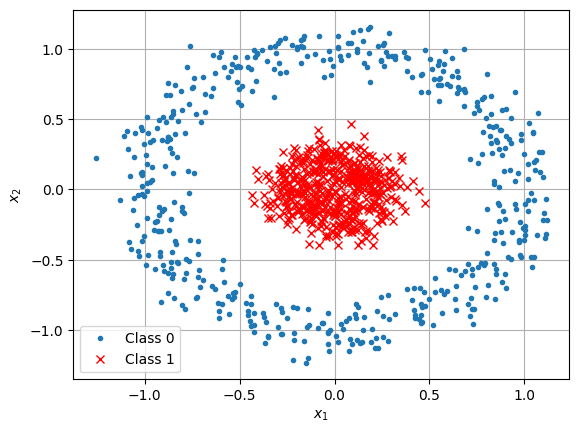

In [ ]:
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)

plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'rx', label='Class 1')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()
#plt.savefig('distribution_of_classes', dpi=600)
plt.show()

In [ ]:
# Split array into random train and test subsets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

### Decision Tree

+ A biblioteca SciKit-Learn implementa o algoritmo da árvore de decisão para classificação através da classe `DecisionTreeClassifier`.

+ Em sua versão atual, a biblioteca não suporta atributos categóricos, apenas numéricos.

+ Documentação: [Decision Trees](https://scikit-learn.org/stable/modules/tree.html#decision-trees)

In [ ]:
# Create classifier.
# Parameter "criterion" can assume either 'gini' or 'entropy' values.
clf = DecisionTreeClassifier(criterion='entropy', random_state=seed)

# Fit the classifier on the training features and labels.
clf.fit(X_train, y_train)

# Use the trained classifier to predict labels for the test features.
y_pred = clf.predict(X_train)

# Calculate and return the accuracy on the test data
train_acc = accuracy_score(y_train, y_pred)

# Use the trained classifier to predict labels for the test features.
y_pred = clf.predict(X_test)

# Calculate and return the accuracy on the test data
test_acc = accuracy_score(y_test, y_pred)

print('Train accuracy: ', train_acc)
print('Test accuracy: ', test_acc)

Train accuracy:  1.0
Test accuracy:  1.0


#### Desenhando a àrvore.

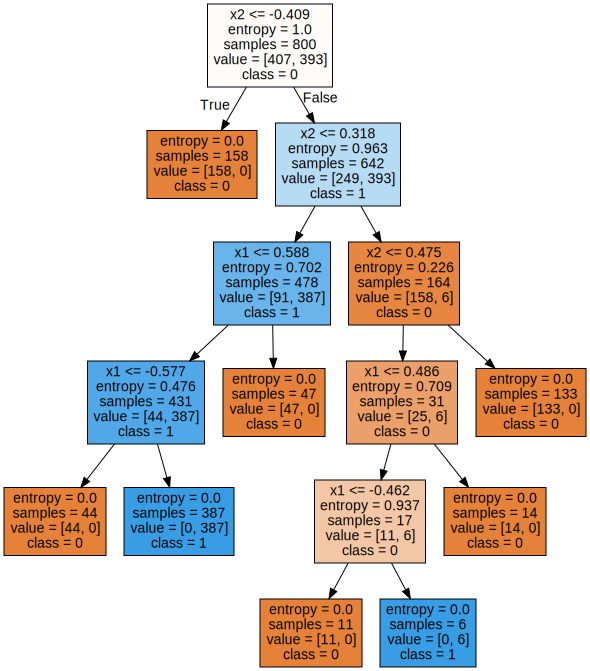

In [ ]:
tree_data = tree.export_graphviz(clf, out_file=None, class_names=['0','1'], feature_names=['x1','x2'], filled=True)
# Draw graph
graph = graphviz.Source(tree_data, format="png")
graph

#### Definição de algumas informações mostradas na árvore.

+ **samples**: número de amostras daquele nó.

+ **value**: indica o número de amostras por classe que se têm naquele nó antes da decisão.

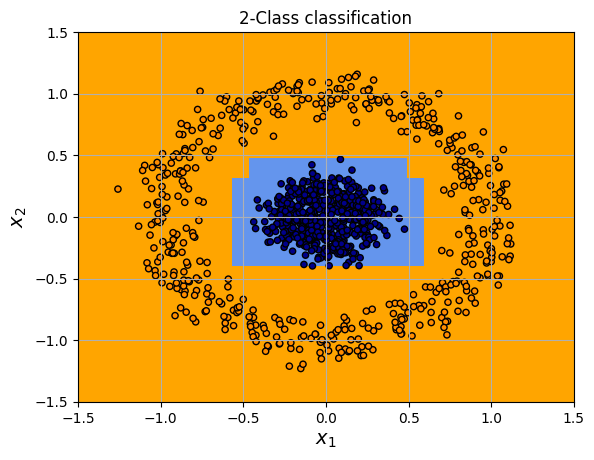

In [ ]:
# Step size in the mesh.
h = .02

# Create color maps
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

# Plot the decision boundary. For that, we will assign a color to each point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot.
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# Plot also the training points.
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title("2-Class classification")
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()

#plt.savefig('decision_boundary_dt.png', dpi=600)
plt.show()

#### Observação

+ Percebam que as fronteiras de decisão são paralelas aos eixos.


+ Isso é uma característica das árvores de decisão devido à sequência de regras criada.